In [1]:
import pandas as pd
import csv
import sys
import os

import numpy as np
import shutil
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)

mimic_path = "C:\\Users\\김한재\\Desktop\\ONEASH_local\\Delirium-Prediction\\mostafaalishahi\\Delirium_prediction_models\\Data\\mimic-iii-clinical-database-1.4"
root_path = "the directory that includes the main csv data"
data_processed_path = "C:\\Users\\김한재\\Desktop\\ONEASH_local\\Delirium-Prediction\\mostafaalishahi\\Delirium_prediction_models\\Data\\preprocessed"

In [2]:
all_data_deli = pd.read_csv(os.path.join(data_processed_path, 'all_data_delirium_mimic.csv'))

In [3]:
all_data_deli['GENDER'].value_counts()

GENDER
2    351180
1    272250
Name: count, dtype: int64

In [4]:
all_data_deli.loc[all_data_deli['CAM-ICU MS change'].notnull(),'CAM-ICU MS Change'] = all_data_deli['CAM-ICU MS change']

In [5]:
col_order = ['ICUSTAY_ID','BIN','HOURS','AGE', 'GENDER', 'Height','Weight','PATIENTWEIGHT',
             'Oxygen Saturation', 'Heart Rate','Temperature C', 'Temperature F','WBC',
             'Sodium','BUN','Glucose','direct bilirubin','Hemoglobin','Platelets',
             'Potassium','Chloride','Bicarbonate','Creatinine','ALT','AST','Alkaline Phosphate',
             'Delirium assessment','CAM-ICU MS Change','CAM-ICU Inattention','CAM-ICU Altered LOC',
             'CAM-ICU Disorganized thinking', 
             'CAM-ICU RASS LOC']
            

In [6]:
all_data_deli = all_data_deli[col_order]

In [7]:
all_data_deli.head(1)

,ICUSTAY_ID,BIN,HOURS,AGE,GENDER,Height,Weight,PATIENTWEIGHT,Oxygen Saturation,Heart Rate,Temperature C,Temperature F,WBC,Sodium,BUN,Glucose,direct bilirubin,Hemoglobin,Platelets,Potassium,Chloride,Bicarbonate,Creatinine,ALT,AST,Alkaline Phosphate,Delirium assessment,CAM-ICU MS Change,CAM-ICU Inattention,CAM-ICU Altered LOC,CAM-ICU Disorganized thinking,CAM-ICU RASS LOC
0,200001,0,0.896667,61,1,NaN,60.39,NaN,97.0,113.0,NaN,99.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
all_data_deli.groupby(['ICUSTAY_ID']).head(1).shape

(7292, 32)

# CAM Positive selection

In [11]:
#Positive CAM-ICU
feature1_pos = all_data_deli['CAM-ICU MS Change']==1
feature2_pos = (all_data_deli['CAM-ICU Inattention']==1) | (all_data_deli['CAM-ICU Inattention']==4)
feature3_pos = all_data_deli['CAM-ICU Altered LOC']==1
feature4_pos = all_data_deli['CAM-ICU Disorganized thinking']==1
cam_pos = all_data_deli[(feature1_pos&feature2_pos)&(feature3_pos|feature4_pos)]

In [12]:
cam_pos = all_data_deli[(feature1_pos&feature2_pos)&(feature3_pos|feature4_pos)]

In [13]:
feature1_pos.sum(),feature2_pos.sum(),feature3_pos.sum(),feature4_pos.sum()

(np.int64(9537), np.int64(6341), np.int64(4738), np.int64(766))

In [14]:
#Statistics of dataset
print("ICU Stays with CAM positive {0}" .format(cam_pos.ICUSTAY_ID.nunique()))
print("Unique ICU Stays {0} \n" .format(all_data_deli.ICUSTAY_ID.nunique()))

print("No. of records with CAM positive {0}" .format(cam_pos.shape[0]))
print("Total No. of records {0}" .format(all_data_deli.shape[0]))

ICU Stays with CAM positive 1339
Unique ICU Stays 7292 

No. of records with CAM positive 5303
Total No. of records 623430


In [15]:
pos_id = cam_pos.ICUSTAY_ID.unique()
cam_pos_df = all_data_deli[all_data_deli['ICUSTAY_ID'].isin(pos_id)]
all_data_deli['CAM'] = np.nan
((feature1_pos&feature2_pos)&(feature3_pos|feature4_pos)).sum()

np.int64(5303)

In [16]:
all_data_deli.loc[((feature1_pos&feature2_pos)&(feature3_pos|feature4_pos)),'CAM']=1
all_data_deli['CAM'].fillna(value=0,inplace=True)
all_data_deli['CAM'].value_counts()

C:\Users\김한재\AppData\Local\Temp\ipykernel_13900\2057076142.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  all_data_deli['CAM'].fillna(value=0,inplace=True)


CAM
1.0    5303
Name: count, dtype: int64

In [17]:
all_data_deli.columns

Index(['ICUSTAY_ID', 'BIN', 'HOURS', 'AGE', 'GENDER', 'Height', 'Weight',
       'PATIENTWEIGHT', 'Oxygen Saturation', 'Heart Rate', 'Temperature C',
       'Temperature F', 'WBC', 'Sodium', 'BUN', 'Glucose', 'direct bilirubin',
       'Hemoglobin', 'Platelets', 'Potassium', 'Chloride', 'Bicarbonate',
       'Creatinine', 'ALT', 'AST', 'Alkaline Phosphate', 'Delirium assessment',
       'CAM-ICU MS Change', 'CAM-ICU Inattention', 'CAM-ICU Altered LOC',
       'CAM-ICU Disorganized thinking', 'CAM-ICU RASS LOC', 'CAM'],
      dtype='str')

In [18]:
all_data_deli.loc[all_data_deli['Weight'].notnull(),'PATIENTWEIGHT'] = all_data_deli['Weight']

In [19]:
def fahr_to_celsius(temp_fahr):
    """Convert Fahrenheit to Celsius
    Return Celsius conversion of input"""
    temp_celsius = (temp_fahr - 32) * 5 / 9
    return temp_celsius

In [20]:
all_data_deli["Temperature F"].describe()

count    158115.000000
mean         98.436112
std          13.144232
min           0.000000
25%          97.700000
50%          98.400000
75%          99.200000
max        4867.350000
Name: Temperature F, dtype: float64

In [21]:
all_data_deli["Temperature F"] = fahr_to_celsius(all_data_deli["Temperature F"])

In [22]:
all_data_deli["Temperature F"].describe()

count    158115.000000
mean         36.908951
std           7.302351
min         -17.777778
25%          36.500000
50%          36.888889
75%          37.333333
max        2686.305556
Name: Temperature F, dtype: float64

In [23]:
all_data_deli.loc[all_data_deli['Temperature F'].notnull(),'Temperature C'] = all_data_deli['Temperature F']

In [24]:
all_data_deli[['Temperature F','Temperature C']].describe()

,Temperature F,Temperature C
count,158115.000000,176614.000000
mean,36.908951,36.943143
std,7.302351,7.010231
min,-17.777778,-17.777778
25%,36.500000,36.500000
50%,36.888889,36.888889
75%,37.333333,37.333333
max,2686.305556,2686.305556


In [25]:
all_data_deli[['PATIENTWEIGHT','Weight']].describe()

,PATIENTWEIGHT,Weight
count,497581.000000,15775.000000
mean,82.740068,81.433787
std,27.269308,24.975667
min,0.000000,0.000000
25%,66.400000,65.745000
50%,78.800000,78.000000
75%,95.000000,93.194167
max,710.400000,710.400000


In [26]:
all_data_deli.head()

,ICUSTAY_ID,BIN,HOURS,AGE,GENDER,Height,Weight,PATIENTWEIGHT,Oxygen Saturation,Heart Rate,Temperature C,Temperature F,WBC,Sodium,BUN,Glucose,direct bilirubin,Hemoglobin,Platelets,Potassium,Chloride,Bicarbonate,Creatinine,ALT,AST,Alkaline Phosphate,Delirium assessment,CAM-ICU MS Change,CAM-ICU Inattention,CAM-ICU Altered LOC,CAM-ICU Disorganized thinking,CAM-ICU RASS LOC,CAM
0,200001,0,0.896667,61,1,NaN,60.39,60.39,97.0,113.0,37.277778,37.277778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,200001,1,1.896667,61,1,NaN,NaN,NaN,98.0,108.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,200001,2,2.896667,61,1,NaN,NaN,NaN,98.0,110.0,NaN,NaN,NaN,NaN,NaN,118.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,200001,3,3.896667,61,1,NaN,NaN,NaN,96.0,102.0,37.666667,37.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,200001,4,4.913333,61,1,NaN,NaN,NaN,94.0,108.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
all_data_deli.BIN.describe()

count    623430.000000
mean        117.615912
std         167.168145
min         -23.000000
25%          22.000000
50%          57.000000
75%         146.000000
max        2082.000000
Name: BIN, dtype: float64

In [28]:
all_data_deli[all_data_deli.BIN < 0].shape

(2935, 33)

In [29]:
data_copy  = all_data_deli.copy()

In [30]:
data_copy.head()

,ICUSTAY_ID,BIN,HOURS,AGE,GENDER,Height,Weight,PATIENTWEIGHT,Oxygen Saturation,Heart Rate,Temperature C,Temperature F,WBC,Sodium,BUN,Glucose,direct bilirubin,Hemoglobin,Platelets,Potassium,Chloride,Bicarbonate,Creatinine,ALT,AST,Alkaline Phosphate,Delirium assessment,CAM-ICU MS Change,CAM-ICU Inattention,CAM-ICU Altered LOC,CAM-ICU Disorganized thinking,CAM-ICU RASS LOC,CAM
0,200001,0,0.896667,61,1,NaN,60.39,60.39,97.0,113.0,37.277778,37.277778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,200001,1,1.896667,61,1,NaN,NaN,NaN,98.0,108.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,200001,2,2.896667,61,1,NaN,NaN,NaN,98.0,110.0,NaN,NaN,NaN,NaN,NaN,118.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,200001,3,3.896667,61,1,NaN,NaN,NaN,96.0,102.0,37.666667,37.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,200001,4,4.913333,61,1,NaN,NaN,NaN,94.0,108.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
data_copy.rename(columns={"ICUSTAY_ID": "patientunitstayid", "BIN": "itemoffset",
                          "GENDER": "gender","AGE": "age","Height": "admissionheight","PATIENTWEIGHT": "admissionweight",
                         "Heart Rate": "Heart Rate","Oxygen Saturation": "O2 Saturation","Glucose": "glucose","Temperature C": "Temperature (C)",
                         "Sodium": "sodium","BUN": "BUN","WBC": "WBC x 1000",
                         "Bilirubin": "direct bilirubin"},inplace=True)

In [32]:
def check(x):
    try:
        x = float(str(x).strip())
    except:
        x = np.nan
    return x

def check_itemvalue(df):
    for c in df.columns:
        df[c] = df[c].apply(lambda x: check(x))
    return df

# labelling

In [33]:
data_copy.columns

Index(['patientunitstayid', 'itemoffset', 'HOURS', 'age', 'gender',
       'admissionheight', 'Weight', 'admissionweight', 'O2 Saturation',
       'Heart Rate', 'Temperature (C)', 'Temperature F', 'WBC x 1000',
       'sodium', 'BUN', 'glucose', 'direct bilirubin', 'Hemoglobin',
       'Platelets', 'Potassium', 'Chloride', 'Bicarbonate', 'Creatinine',
       'ALT', 'AST', 'Alkaline Phosphate', 'Delirium assessment',
       'CAM-ICU MS Change', 'CAM-ICU Inattention', 'CAM-ICU Altered LOC',
       'CAM-ICU Disorganized thinking', 'CAM-ICU RASS LOC', 'CAM'],
      dtype='str')

In [34]:
order_columns = ['patientunitstayid','itemoffset', 
       'gender', 'age', 'admissionheight',
       'admissionweight', 'Heart Rate', 'O2 Saturation', 'glucose', 'Temperature (C)',
       'sodium','BUN', 'WBC x 1000', 'direct bilirubin',
       'Hemoglobin','Platelets','Potassium', 'Chloride', 'Bicarbonate', 'Creatinine',
       'ALT', 'AST', 'Alkaline Phosphate','CAM']

In [35]:
data_copy = data_copy[data_copy['itemoffset'] > -7]
label_deli = data_copy.copy()
label_deli['labelrec'] = np.nan
label_deli.loc[label_deli['CAM']==1,'labelrec']=1
label_deli.loc[label_deli['CAM']==0,'labelrec']=0
label_deli['labelpt'] = np.nan
pos_cam_coh = label_deli[label_deli['labelrec']==1]['patientunitstayid'].unique()
label_deli.loc[label_deli['patientunitstayid'].isin(pos_cam_coh), 'labelpt']=1
label_deli.loc[~(label_deli['patientunitstayid'].isin(pos_cam_coh)), 'labelpt']=0

In [36]:
label_deli.groupby('patientunitstayid').count().shape

(7292, 34)

# Add Sofa score to dataframe

In [38]:
data_copy = label_deli[order_columns]
df_mimic = data_copy.copy()
sofa = pd.read_csv(os.path.join(data_processed_path, 'mimic_pivoted_sofa.csv'))
df_mimic['day'] = np.nan
for i in range(-7,1000):
    df_mimic.loc[((df_mimic['itemoffset'] <= i*24) & (df_mimic['itemoffset'] >= (i-1)*24)),'day'] = i  
sofa.rename(columns={'icustay_id':'patientunitstayid'},inplace=True)
set_sofa = set(sofa.patientunitstayid.unique())
set_mimic = set(df_mimic.patientunitstayid.unique())
inters = list(set_sofa.intersection(set_mimic))
print(len(inters))
new_df = pd.merge(df_mimic, sofa, how='left', left_on=['patientunitstayid','day'],right_on=['patientunitstayid','day'])

7292


In [39]:
new_df.head()

,patientunitstayid,itemoffset,gender,age,admissionheight,admissionweight,Heart Rate,O2 Saturation,glucose,Temperature (C),sodium,BUN,WBC x 1000,direct bilirubin,Hemoglobin,Platelets,Potassium,Chloride,Bicarbonate,Creatinine,ALT,AST,Alkaline Phosphate,CAM,day,sofa,sofa_wo_gcs
0,200001,0,1,61,NaN,60.39,113.0,97.0,NaN,37.277778,NaN,NaN,NaN,NaN,NaN,NaN,4.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.0,3.0
1,200001,1,1,61,NaN,NaN,108.0,98.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.0,3.0
2,200001,2,1,61,NaN,NaN,110.0,98.0,118.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.0,3.0
3,200001,3,1,61,NaN,NaN,102.0,96.0,NaN,37.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.0,3.0
4,200001,4,1,61,NaN,NaN,108.0,94.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.0,3.0


In [40]:
new_df.columns

Index(['patientunitstayid', 'itemoffset', 'gender', 'age', 'admissionheight',
       'admissionweight', 'Heart Rate', 'O2 Saturation', 'glucose',
       'Temperature (C)', 'sodium', 'BUN', 'WBC x 1000', 'direct bilirubin',
       'Hemoglobin', 'Platelets', 'Potassium', 'Chloride', 'Bicarbonate',
       'Creatinine', 'ALT', 'AST', 'Alkaline Phosphate', 'CAM', 'day', 'sofa',
       'sofa_wo_gcs'],
      dtype='str')

## Add other variables to dataframe

In [42]:
data_copy = new_df
df_mimic = data_copy.copy()
df_vent = pd.read_csv(os.path.join(data_processed_path, 'mimic_wes.csv'))
df_vent.rename(columns={'icustay_id':'patientunitstayid'},inplace=True)
new_df = pd.merge(df_mimic, df_vent, how='left',left_on=['patientunitstayid','itemoffset'],right_on=['patientunitstayid','hr'])

In [43]:
new_df.columns

Index(['patientunitstayid', 'itemoffset', 'gender', 'age', 'admissionheight',
       'admissionweight', 'Heart Rate', 'O2 Saturation', 'glucose',
       'Temperature (C)', 'sodium', 'BUN', 'WBC x 1000', 'direct bilirubin',
       'Hemoglobin', 'Platelets', 'Potassium', 'Chloride', 'Bicarbonate',
       'Creatinine', 'ALT', 'AST', 'Alkaline Phosphate', 'CAM', 'day', 'sofa',
       'sofa_wo_gcs', 'hr', 'vent_flag', 'rate_dopamine', 'rate_epinephrine',
       'rate_norepinephrine', 'rate_phenylephrine', 'fluidin', 'fluidout'],
      dtype='str')

In [44]:
columns_order = ['patientunitstayid', 'itemoffset', 'gender', 'age', 'admissionheight',
       'admissionweight', 'Heart Rate', 'O2 Saturation', 'glucose',
       'Temperature (C)', 'sodium', 'BUN', 'WBC x 1000', 'direct bilirubin',
       'Hemoglobin', 'Platelets', 'Potassium', 'Chloride', 'Bicarbonate',
       'Creatinine', 'ALT', 'AST', 'Alkaline Phosphate', 'sofa', 'sofa_wo_gcs',
       'vent_flag','rate_dopamine', 'rate_epinephrine', 'rate_norepinephrine',
       'rate_phenylephrine', 'fluidin', 'fluidout','CAM']

In [45]:
new_df = new_df[columns_order]

## Imputation patient wise for weight and height

In [46]:
for i in ['admissionheight','admissionweight']:
    new_df[i] = new_df.groupby("patientunitstayid")[i].transform(lambda v: v.ffill())
    new_df[i] = new_df.groupby("patientunitstayid")[i].transform(lambda v: v.bfill())

# Missing values

## record-wise

In [48]:
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
columns = columns_order 
percent_missing = new_df[columns].isnull().sum() * 100 / len(new_df)
missing_value_df = pd.DataFrame({'column_name': columns,'percent_missing': percent_missing})
missing_value_df.sort_values('percent_missing', inplace=True)
missing_value_df.reset_index(inplace=True, drop=True)
missing_value_df

,column_name,percent_missing
0,patientunitstayid,0.000000
1,itemoffset,0.000000
2,gender,0.000000
3,age,0.000000
4,sofa_wo_gcs,0.206408
5,sofa,0.206408
6,admissionweight,0.300757
7,rate_phenylephrine,0.596039
8,rate_norepinephrine,0.596039
9,vent_flag,0.596039


## Patient-wise

In [49]:
df_g = new_df[columns_order].groupby("patientunitstayid").apply(lambda x: x.notnull().mean())

for i in df_g.columns:
    df_g[i] = df_g[i].replace({0:np.nan})

    
    #after Imputation
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
columns = df_g.columns
percent_missing = df_g.isnull().sum() * 100 / len(df_g)
missing_value_df = pd.DataFrame({'column_name': columns,'percent_missing': percent_missing})
missing_value_df.sort_values('percent_missing', inplace=True)
missing_value_df.reset_index(inplace=True, drop=True)
missing_value_df

,column_name,percent_missing
0,itemoffset,0.000000
1,gender,0.000000
2,age,0.000000
3,rate_norepinephrine,0.000000
4,rate_phenylephrine,0.000000
5,fluidin,0.000000
6,sofa_wo_gcs,0.000000
7,fluidout,0.000000
8,vent_flag,0.000000
9,rate_dopamine,0.000000


# Correlation

In [50]:
new_df.rename(index=str, columns={"admissionheight": "Height",
                                  "admissionweight":"Weight",
                                  "glucose" : "Glucose",
                                  "sodium" : "Sodium",
                                  "vent_flag" : "Ventilation",
                                  "rate_dopamine" : "Dopamine",
                                  "rate_epinephrine" : "Epinephrine",
                                  "rate_norepinephrine":"Norepinephrine",
                                  "rate_phenylephrine":"Phenylephrine",
                                  "gender":"Gender",
                                  "sofa":"Sofa",
                                  "sofa_wo_gcs":"Sofa_wo_gcs",
                                  "Temperature (C)" : "Temperature",
                                  "WBC x 1000": "WBC",
                                  "age":"Age"}, inplace=True)

In [51]:
new_df['Epinephrine'].fillna(value=0,inplace=True)
new_df['Norepinephrine'].fillna(value=0,inplace=True) 
new_df['Phenylephrine'].fillna(value=0,inplace=True)
new_df['Dopamine'].fillna(value=0,inplace=True)


C:\Users\김한재\AppData\Local\Temp\ipykernel_13900\914743594.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  new_df['Epinephrine'].fillna(value=0,inplace=True)
C:\Users\김한재\AppData\Local\Temp\ipykernel_13900\914743594.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment usi

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
621095    0.0
621096    0.0
621097    0.0
621098    0.0
621099    0.0
Name: Dopamine, Length: 621100, dtype: float64

In [52]:
new_df['Vasopressor dose'] = np.nan
new_df['Vasopressor dose'] = new_df['Epinephrine']+new_df['Norepinephrine'] + new_df['Phenylephrine']/10 + new_df['Dopamine']/2
new_df.drop(columns=['Epinephrine', 'Norepinephrine','Phenylephrine','Dopamine'],inplace=True)


In [53]:
new_df['Vasopressor dose'].notnull().sum()

np.int64(617398)

In [54]:
columns_for_corr = ['Age', 'Height',
       'Weight', 'Heart Rate', 'O2 Saturation', 'Glucose',
       'Temperature', 'Sodium', 'BUN', 'WBC', 
       'Hemoglobin', 'Platelets', 'Potassium', 'Chloride', 'Bicarbonate',
       'Creatinine','Ventilation','Vasopressor dose','Gender','Sofa', 'Sofa_wo_gcs',  'CAM']

In [55]:
new_df['Vasopressor dose'].notnull().sum()

np.int64(617398)

In [56]:
new_df[columns_for_corr].columns

Index(['Age', 'Height', 'Weight', 'Heart Rate', 'O2 Saturation', 'Glucose',
       'Temperature', 'Sodium', 'BUN', 'WBC', 'Hemoglobin', 'Platelets',
       'Potassium', 'Chloride', 'Bicarbonate', 'Creatinine', 'Ventilation',
       'Vasopressor dose', 'Gender', 'Sofa', 'Sofa_wo_gcs', 'CAM'],
      dtype='str')

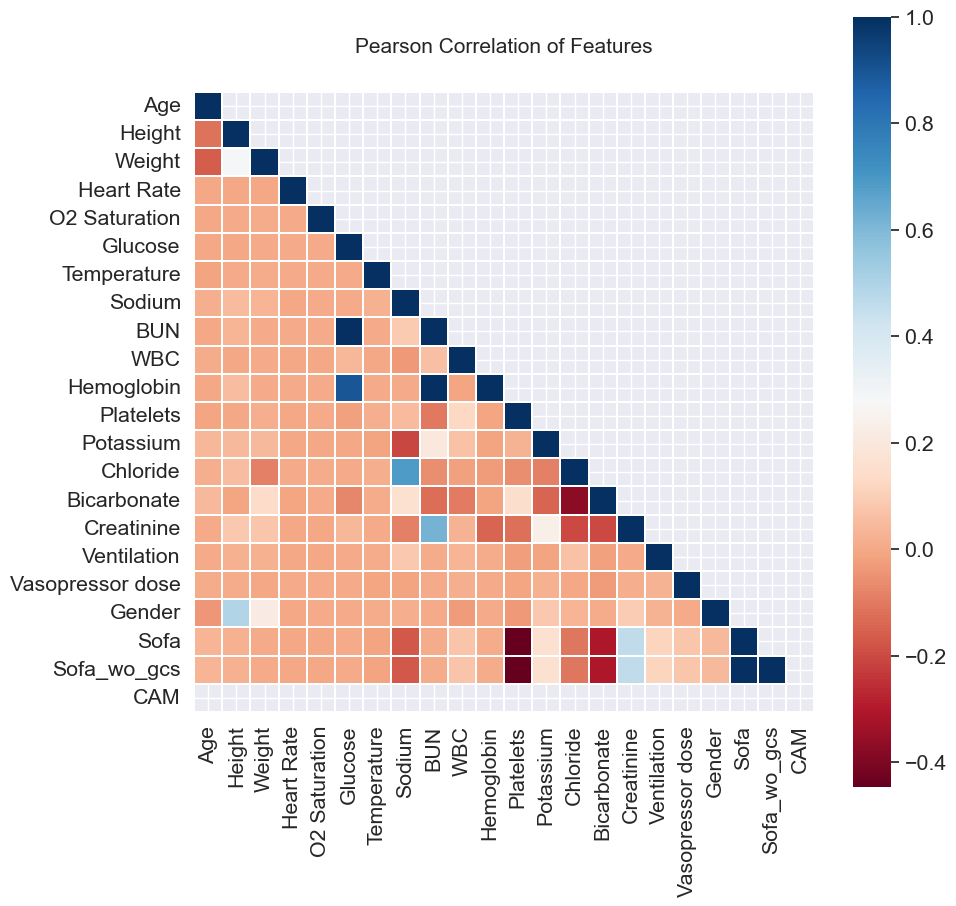

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

colormap = plt.cm.RdBu

mask = np.zeros(new_df[columns_for_corr].corr().shape, dtype=bool)
mask[np.tril_indices(len(mask))] = True
mask = ~mask

plt.figure(figsize=(10,10))

sns.set(font_scale=1.4)
plt.title('Pearson Correlation of Features', y=1.05, size=15)

sns.heatmap(new_df[columns_for_corr].corr(), mask = mask, linewidths=0.1,vmax=1.0, square=True, cmap=colormap, linecolor='white', annot=False)

plt.savefig('mimic_corr.png',dpi=450, facecolor='white', bbox_inches = 'tight',transparent=True)
plt.show()

# Save not imputed data

In [58]:
los = pd.read_csv(os.path.join(mimic_path, 'ICUSTAYS.csv'))
los = los[['ICUSTAY_ID','LOS']]
los.head()
los['LOS'] = los['LOS'] * 24
los.rename(columns={"ICUSTAY_ID": "patientunitstayid"},inplace=True)
new_df_los = pd.merge(new_df, los, how='left', left_on=['patientunitstayid'],right_on=['patientunitstayid'])
print(new_df_los.patientunitstayid.nunique())
new_df_los = new_df_los[new_df_los['LOS']>=24] #CHANGE TO 48
new_df_los = new_df_los[new_df_los['itemoffset'] > 0] #CHANGE TO ZERO
new_df_los_nodups = new_df_los.drop_duplicates()

7292


In [59]:
new_df_los_nodups.groupby("patientunitstayid").count().shape

(6294, 30)

In [60]:
label_deli = new_df_los_nodups.copy()
label_deli['labelrec'] = np.nan
label_deli.loc[label_deli['CAM']==1,'labelrec']=1
label_deli.loc[label_deli['CAM']==0,'labelrec']=0
label_deli['labelpt'] = np.nan
pos_cam_coh = label_deli[label_deli['labelrec']==1]['patientunitstayid'].unique()
label_deli.loc[label_deli['patientunitstayid'].isin(pos_cam_coh), 'labelpt']=1
label_deli.loc[~(label_deli['patientunitstayid'].isin(pos_cam_coh)), 'labelpt']=0
pos_cam_df = label_deli[label_deli['labelpt']==1]
neg_cam_df = label_deli[label_deli['labelpt']==0]
pos_cam_df.reset_index(inplace=True)
pos_cam_df = pos_cam_df.drop(columns=['index'])
neg_cam_df.reset_index(inplace=True)
neg_cam_df = neg_cam_df.drop(columns=['index'])
pos_cam_df.to_csv(os.path.join(data_processed_path, 'pos_mimic_notimputed_24los.csv'), index=False)
neg_cam_df.to_csv(os.path.join(data_processed_path, 'neg_mimic_notimputed_24los.csv'), index=False)

# Imputation

In [61]:
new_df = label_deli.copy()

In [68]:
mean_columns = ['Age', 'Height','Weight']

In [69]:
# mean Imputation of each patient
for i in mean_columns:
    new_df[i].fillna(new_df.groupby("patientunitstayid")[i].transform('mean'),inplace=True)

C:\Users\김한재\AppData\Local\Temp\ipykernel_13900\3143220888.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  new_df[i].fillna(new_df.groupby("patientunitstayid")[i].transform('mean'),inplace=True)


In [70]:
for i in mean_columns:
    new_df[i] = new_df[i].fillna(new_df[i].mean())

In [71]:
new_df.columns

Index(['patientunitstayid', 'itemoffset', 'Gender', 'Age', 'Height', 'Weight',
       'Heart Rate', 'O2 Saturation', 'Glucose', 'Temperature', 'Sodium',
       'BUN', 'WBC', 'direct bilirubin', 'Hemoglobin', 'Platelets',
       'Potassium', 'Chloride', 'Bicarbonate', 'Creatinine', 'ALT', 'AST',
       'Alkaline Phosphate', 'Sofa', 'Sofa_wo_gcs', 'Ventilation', 'fluidin',
       'fluidout', 'CAM', 'Vasopressor dose', 'LOS', 'labelrec', 'labelpt'],
      dtype='str')

In [72]:
zero_columns = ['vent_flag', 'rate_dopamine', 'rate_epinephrine', 'rate_norepinephrine',
       'rate_phenylephrine']

In [73]:
new_df[zero_columns] = new_df[zero_columns].fillna(value=0)

KeyError: "None of [Index(['vent_flag', 'rate_dopamine', 'rate_epinephrine', 'rate_norepinephrine',\n       'rate_phenylephrine'],\n      dtype='str')] are in the [columns]"

In [75]:
# PATIENT WISE
df_g = new_df[columns_order].groupby("patientunitstayid").apply(lambda x: x.notnull().mean())
for i in df_g.columns:
    df_g[i] = df_g[i].replace({0:np.nan})
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
columns = df_g.columns
percent_missing = df_g.isnull().sum() * 100 / len(df_g)
missing_value_df = pd.DataFrame({'column_name': columns,'percent_missing': percent_missing})
missing_value_df.sort_values('percent_missing', inplace=True)
missing_value_df.reset_index(inplace=True, drop=True)
missing_value_df

KeyError: "['gender', 'age', 'admissionheight', 'admissionweight', 'glucose', 'Temperature (C)', 'sodium', 'WBC x 1000', 'sofa', 'sofa_wo_gcs', 'vent_flag', 'rate_dopamine', 'rate_epinephrine', 'rate_norepinephrine', 'rate_phenylephrine'] not in index"

# FFill

In [76]:
forward_columns = ['Heart Rate', 'O2 Saturation', 'glucose',
       'Temperature (C)', 'sodium', 'BUN', 'WBC x 1000', 'direct bilirubin',
       'Hemoglobin', 'Platelets', 'Potassium', 'Chloride', 'Bicarbonate',
       'Creatinine', 'ALT', 'AST', 'Alkaline Phosphate', 'sofa', 'sofa_wo_gcs','fluidin', 'fluidout']

In [77]:
for i in forward_columns:
    new_df[i] = new_df.groupby("patientunitstayid")[i].transform(lambda v: v.ffill())

KeyError: 'Column not found: glucose'

In [78]:
# PATIENT WISE

df_g = new_df[columns_order].groupby("patientunitstayid").apply(lambda x: x.notnull().mean())

for i in df_g.columns:
    df_g[i] = df_g[i].replace({0:np.nan})

import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
columns = df_g.columns
percent_missing = df_g.isnull().sum() * 100 / len(df_g)
missing_value_df = pd.DataFrame({'column_name': columns,'percent_missing': percent_missing})
missing_value_df.sort_values('percent_missing', inplace=True)
missing_value_df.reset_index(inplace=True, drop=True)
missing_value_df

KeyError: "['gender', 'age', 'admissionheight', 'admissionweight', 'glucose', 'Temperature (C)', 'sodium', 'WBC x 1000', 'sofa', 'sofa_wo_gcs', 'vent_flag', 'rate_dopamine', 'rate_epinephrine', 'rate_norepinephrine', 'rate_phenylephrine'] not in index"

# BFill

In [72]:
back_columns = forward_columns

In [73]:
for i in back_columns:
    new_df[i] = new_df.groupby("patientunitstayid")[i].transform(lambda v: v.bfill())

In [ ]:
#After Bfill
df_g = new_df[columns_order].groupby("patientunitstayid").apply(lambda x: x.notnull().mean())

for i in df_g.columns:
    df_g[i] = df_g[i].replace({0:np.nan})

import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
columns = df_g.columns
percent_missing = df_g.isnull().sum() * 100 / len(df_g)
missing_value_df = pd.DataFrame({'column_name': columns,'percent_missing': percent_missing})
missing_value_df.sort_values('percent_missing', inplace=True)
missing_value_df.reset_index(inplace=True, drop=True)
missing_value_df

# Drop columns with high missing rate (ALT,AST,Alk Ph, Dir Bil)


In [ ]:
new_df.drop(columns=['ALT', 'AST','Alkaline Phosphate','direct bilirubin','fluidin', 'fluidout'],inplace=True)
print(new_df.patientunitstayid.nunique())
print(new_df.shape)

# Length of stay

In [ ]:
los = pd.read_csv(os.path.join(mimic_path, 'ICUSTAYS.csv'))
los = los[['ICUSTAY_ID','LOS']]
los.head()
los['LOS'] = los['LOS'] * 24
los.rename(columns={"ICUSTAY_ID": "patientunitstayid"},inplace=True)
new_df_los = pd.merge(new_df, los, how='left', left_on=['patientunitstayid'],right_on=['patientunitstayid'])
print(new_df_los.patientunitstayid.nunique())
new_df_los = new_df_los[new_df_los['LOS']>=24] #CHANGE TO 48
new_df_los = new_df_los[new_df_los['itemoffset'] > 0] #CHANGE TO ZERO
new_df_los_nodups = new_df_los.drop_duplicates()

## LOS at least 24/48 hours

### Missing values

In [81]:
columns_order = ['patientunitstayid', 'itemoffset', 'gender', 'age', 'admissionheight',
       'admissionweight', 'Heart Rate', 'O2 Saturation', 'glucose',
       'Temperature (C)', 'sodium', 'BUN', 'WBC x 1000', 'Hemoglobin',
        'Platelets', 'Potassium', 'Chloride', 'Bicarbonate',
       'Creatinine', 'sofa', 'sofa_wo_gcs',
       'vent_flag','rate_dopamine', 'rate_epinephrine', 'rate_norepinephrine',
       'rate_phenylephrine', 'LOS','CAM']

In [ ]:
df_g = new_df_los_nodups[columns_order].groupby("patientunitstayid").apply(lambda x: x.notnull().mean())
for i in df_g.columns:
    df_g[i] = df_g[i].replace({0:np.nan})
#after Imputation
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
columns = df_g.columns
percent_missing = df_g.isnull().sum() * 100 / len(df_g)
missing_value_df = pd.DataFrame({'column_name': columns,'percent_missing': percent_missing})
missing_value_df.sort_values('percent_missing', inplace=True)
missing_value_df.reset_index(inplace=True, drop=True)
missing_value_df

# Drop Patients with missing values

In [83]:
new_df_los_nodups.dropna(subset=['Heart Rate', 'O2 Saturation', 'glucose',
       'Temperature (C)', 'sodium', 'BUN', 'WBC x 1000', 'Hemoglobin',
       'Platelets', 'Potassium', 'Chloride', 'Bicarbonate', 'Creatinine',
       'sofa', 'sofa_wo_gcs', 'vent_flag', 'rate_dopamine', 'rate_epinephrine',
       'rate_norepinephrine', 'rate_phenylephrine'],inplace=True)

In [ ]:
new_df_los_nodups.shape

In [ ]:
new_df_los_nodups.patientunitstayid.nunique()

### split CAM pos and CAM neg

In [87]:
label_deli = new_df_los_nodups.copy()
label_deli['labelrec'] = np.nan
label_deli.loc[label_deli['CAM']==1,'labelrec']=1
label_deli.loc[label_deli['CAM']==0,'labelrec']=0
label_deli['labelpt'] = np.nan

In [88]:
pos_cam_coh = label_deli[label_deli['labelrec']==1]['patientunitstayid'].unique()
label_deli.loc[label_deli['patientunitstayid'].isin(pos_cam_coh), 'labelpt']=1
label_deli.loc[~(label_deli['patientunitstayid'].isin(pos_cam_coh)), 'labelpt']=0

In [ ]:
label_deli.tail(1)

In [90]:
pos_cam_df = label_deli[label_deli['labelpt']==1]
neg_cam_df = label_deli[label_deli['labelpt']==0]
pos_cam_df.reset_index(inplace=True)
pos_cam_df = pos_cam_df.drop(columns=['index'])

neg_cam_df.reset_index(inplace=True)
neg_cam_df = neg_cam_df.drop(columns=['index'])

In [ ]:
pos_cam_df['patientunitstayid'].nunique(),neg_cam_df['patientunitstayid'].nunique()

In [92]:
neg_cam_df['CAM'] = neg_cam_df['labelpt']
pos_cam_df['CAM'] = pos_cam_df['labelpt']

In [93]:
pos_cam_df.to_csv(os.path.join(data_processed_path, 'pos_mimic_imputed_24los.csv'), index=False)
neg_cam_df.to_csv(os.path.join(data_processed_path, 'neg_mimic_imputed_24los.csv'), index=False)

In [94]:
mimic_df = pd.concat([neg_cam_df, pos_cam_df],axis=0)

In [ ]:
mimic_df.patientunitstayid.nunique()